In [2]:
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from nltk.stem import SnowballStemmer
!pip install pymorphy3 pymorphy3-dicts-ru
import pymorphy3

!pip install gensim
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel
!pip install pyLDAvis
import pyLDAvis.gensim_models as gensimvis
!pip install umap-learn[plot]
import umap
import umap.plot

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
def load_and_preprocess_text(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()

    chapters = re.split(r'\n\s*[IVXLCDM]+\s*\n', text)[1:]

    return chapters

chapters = load_and_preprocess_text('/content/drive/MyDrive/Colab Notebooks/Recommendation_systems/war_and_piece.txt')

print(f"Количество глав для анализа: {len(chapters)}")

Количество глав для анализа: 361


In [6]:
def preprocess_russian_text(texts):
    # Инициализация инструментов для русского языка
    stop_words = set(stopwords.words('russian'))
    morph = pymorphy3.MorphAnalyzer()

    # Расширение стоп-слов
    additional_stopwords = ['это', 'как', 'так', 'и', 'в', 'над', 'к', 'до',
                            'не', 'на', 'но', 'за', 'то', 'с', 'ли', 'а', 'во',
                            'от', 'со', 'для', 'о', 'же', 'ну', 'вы', 'бы',
                            'что', 'кто', 'он', 'она', 'этот', 'тот', 'свой',
                            'мой', 'твой', 'весь', 'такой', 'где', 'когда',
                            'даже', 'уж', 'вот', 'би', 'мог', 'этот', 'тот',
                            'свой']
    stop_words.update(additional_stopwords)

    processed_texts = []

    for text in texts:
        # Приведение к нижнему регистру
        text = text.lower()

        # Удаление цифр и лишних символов
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^\w\s]', ' ', text)

        # Токенизация
        tokens = text.split()

        # Удаление стоп-слов и коротких токенов
        tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

        # Лемматизация для русского языка
        lemmatized_tokens = []
        for token in tokens:
            parsed_token = morph.parse(token)[0]
            lemma = parsed_token.normal_form
            lemmatized_tokens.append(lemma)

        processed_texts.append(lemmatized_tokens)

    return processed_texts

processed_chapters = preprocess_russian_text(chapters)

print(f"Пример обработанной главы (первые 30 слов): {processed_chapters[0][:30]}")

Пример обработанной главы (первые 30 слов): ['bien', 'mon', 'prince', 'gênes', 'lucques', 'sont', 'plus', 'que', 'des', 'apanages', 'des', 'поместье', 'famille', 'buonaparte', 'non', 'vous', 'préviens', 'que', 'vous', 'dites', 'pas', 'que', 'nous', 'avons', 'guerre', 'vous', 'vous', 'permettez', 'encore', 'pallier']


Размер словаря до фильтрации: 20333
Частоты самых популярных слов:
[3742, 3405, 2621, 2183, 2140, 2057, 1924, 1347, 1307, 1265, 1244, 1211, 1043, 969, 912, 903, 820, 819, 815, 805, 798, 797, 785, 759, 728]
Распределение:


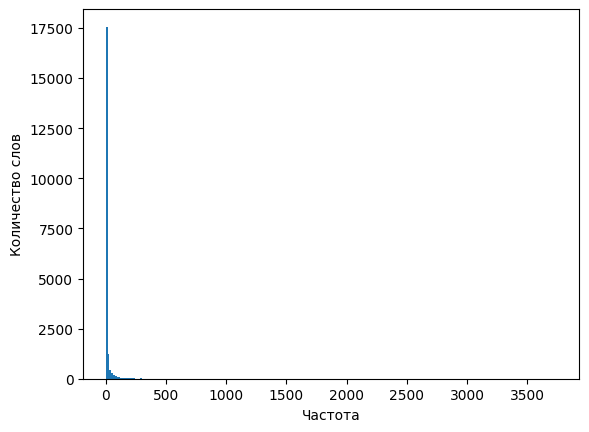

In [7]:
# Создание словаря
id2word = corpora.Dictionary(processed_chapters)

print(f"Размер словаря до фильтрации: {len(id2word)}")
print(f"Частоты самых популярных слов:")
print(sorted(id2word.cfs.values(), reverse=True)[:25])

print(f"Распределение:")
fig, ax = plt.subplots()
ax.hist(id2word.cfs.values(), bins=250)
ax.set_xlabel("Частота")
ax.set_ylabel("Количество слов")
fig.show()

Размер словаря после фильтрации: 2346
Количество документов в корпусе: 361
Пример элемента корпуса (первые 10 элементов):
[(0, 1), (1, 1), (2, 2), (3, 2), (4, 4), (5, 1), (6, 5), (7, 1), (8, 3), (9, 4)]
Распределение:


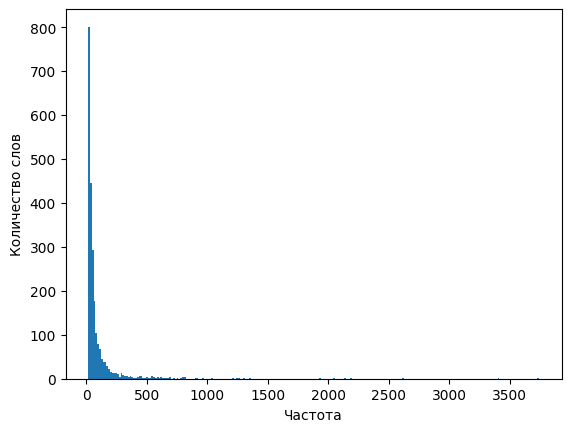

In [8]:
# Фильтрация редких и частых слов
id2word.filter_extremes(no_below=15, no_above=1000)

# Создание корпуса (Bag-of-words представление)
corpus = [id2word.doc2bow(text) for text in processed_chapters]

print(f"Размер словаря после фильтрации: {len(id2word)}")
print(f"Количество документов в корпусе: {len(corpus)}")
print("Пример элемента корпуса (первые 10 элементов):")
print(corpus[0][:10])

print(f"Распределение:")
fig, ax = plt.subplots()
ax.hist(id2word.cfs.values(), bins=250)
ax.set_xlabel("Частота")
ax.set_ylabel("Количество слов")
fig.show()

In [9]:
# Импорт библиотек
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt
import numpy as np

def compute_coherence_values(dictionary, corpus, processed_texts, start=2, limit=15, step=1):
    coherence_values = []
    model_list = []

    for num_topics in range(start, limit, step):
        # Обучение LDA-модели
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,          # Количество проходов для обучения
            alpha='auto',       # Автоматическая настройка параметра alpha
            eta='auto'          # Автоматическая настройка параметра eta (beta)
        )
        model_list.append(model)

        # Расчет когерентности (используется метрика c_v)
        coherencemodel = CoherenceModel(
            model=model,
            texts=processed_texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())

        print(f"Число тем: {num_topics}, Когерентность: {coherencemodel.get_coherence():.4f}")

    return model_list, coherence_values

# Вызов функции для диапазона тем
model_list, coherence_values = compute_coherence_values(
    dictionary=id2word,
    corpus=corpus,
    processed_texts=processed_chapters,
    start=3,
    limit=25,
    step=1
)

Число тем: 3, Когерентность: 0.3400
Число тем: 4, Когерентность: 0.3172
Число тем: 5, Когерентность: 0.3486
Число тем: 6, Когерентность: 0.3535
Число тем: 7, Когерентность: 0.3423
Число тем: 8, Когерентность: 0.3616
Число тем: 9, Когерентность: 0.3793
Число тем: 10, Когерентность: 0.3467
Число тем: 11, Когерентность: 0.3860
Число тем: 12, Когерентность: 0.3694
Число тем: 13, Когерентность: 0.3847
Число тем: 14, Когерентность: 0.3927
Число тем: 15, Когерентность: 0.3819
Число тем: 16, Когерентность: 0.3722
Число тем: 17, Когерентность: 0.3762
Число тем: 18, Когерентность: 0.4035
Число тем: 19, Когерентность: 0.3757
Число тем: 20, Когерентность: 0.3490
Число тем: 21, Когерентность: 0.3641
Число тем: 22, Когерентность: 0.3607
Число тем: 23, Когерентность: 0.3764
Число тем: 24, Когерентность: 0.3574


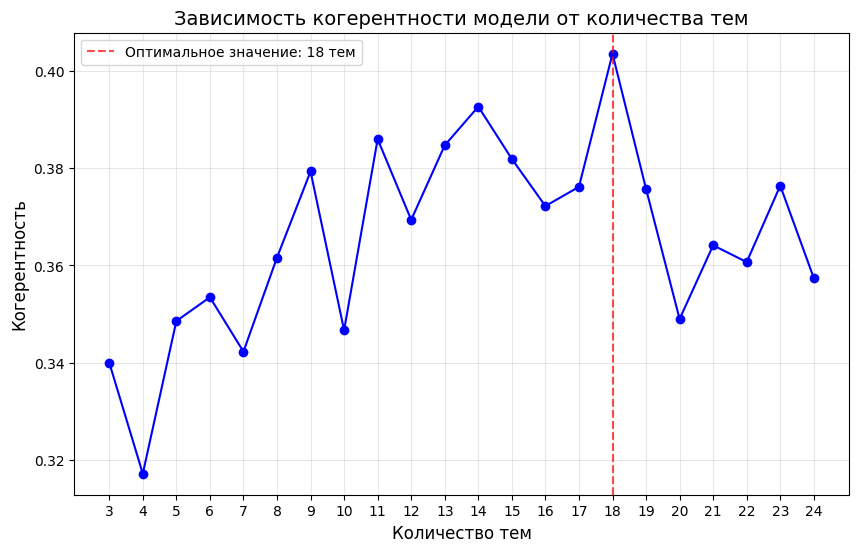


Рекомендуемое количество тем: 18
Со значением когерентности: 0.4035


In [11]:
# Визуализация зависимости когерентности от количества тем
limit = 25
start = 3
step = 1
x = range(start, limit, step)

plt.figure(figsize=(10,6))
plt.plot(x, coherence_values, marker='o', linestyle='-', color='b')
plt.xlabel('Количество тем', fontsize=12)
plt.ylabel('Когерентность', fontsize=12)
plt.title('Зависимость когерентности модели от количества тем', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(x)

# Найдем и отметим точку с максимальной когерентностью
optimal_idx = np.argmax(coherence_values)
optimal_topics = x[optimal_idx]
optimal_coherence = coherence_values[optimal_idx]

plt.axvline(x=optimal_topics, color='r', linestyle='--', alpha=0.7, label=f'Оптимальное значение: {optimal_topics} тем')
plt.legend()

plt.show()

print(f"\nРекомендуемое количество тем: {optimal_topics}")
print(f"Со значением когерентности: {optimal_coherence:.4f}")

In [12]:
# Построение LDA модели
num_topics = 18  # Начальное предположение о количестве тем

lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto',
    eta='auto',
    per_word_topics=True
)

# Вывод тем
print("Обнаруженные темы:")
pprint(lda_model.print_topics(num_words=10))

# Оценка когерентности модели
coherence_model = CoherenceModel(
    model=lda_model,
    texts=processed_chapters,
    dictionary=id2word,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"Когерентность модели: {coherence_score:.4f}")

Обнаруженные темы:
[(0,
  '0.027*"который" + 0.018*"свой" + 0.012*"человек" + 0.012*"пьер" + '
  '0.011*"москва" + 0.011*"жизнь" + 0.009*"говорить" + 0.007*"один" + '
  '0.007*"время" + 0.006*"тот"'),
 (1,
  '0.024*"сказать" + 0.022*"наташа" + 0.014*"который" + 0.014*"говорить" + '
  '0.013*"марья" + 0.012*"княжна" + 0.012*"свой" + 0.011*"князь" + '
  '0.011*"пьер" + 0.010*"знать"'),
 (2,
  '0.097*"пьер" + 0.021*"который" + 0.019*"сказать" + 0.014*"человек" + '
  '0.013*"свой" + 0.008*"француз" + 0.008*"говорить" + 0.007*"лицо" + '
  '0.007*"vous" + 0.006*"рука"'),
 (3,
  '0.032*"николай" + 0.018*"наташа" + 0.016*"сказать" + 0.016*"свой" + '
  '0.015*"говорить" + 0.014*"который" + 0.011*"графиня" + 0.010*"соня" + '
  '0.010*"мать" + 0.008*"ростов"'),
 (4,
  '0.028*"сказать" + 0.020*"командир" + 0.016*"полковой" + 0.013*"говорить" + '
  '0.012*"солдат" + 0.010*"рота" + 0.010*"офицер" + 0.009*"свой" + '
  '0.008*"граф" + 0.008*"долох"'),
 (5,
  '0.039*"долох" + 0.026*"ростов" + 0.025*"ск

In [14]:
import pyLDAvis

# Подготовка данных для визуализации
vis_data = gensimvis.prepare(lda_model, corpus, id2word)

# Сохранение визуализации
pyLDAvis.save_html(vis_data, '/content/drive/MyDrive/Colab Notebooks/Recommendation_systems/lda_visualization.html')

print("Визуализация сохранена в файл 'lda_visualization.html'")

Визуализация сохранена в файл 'lda_visualization.html'


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


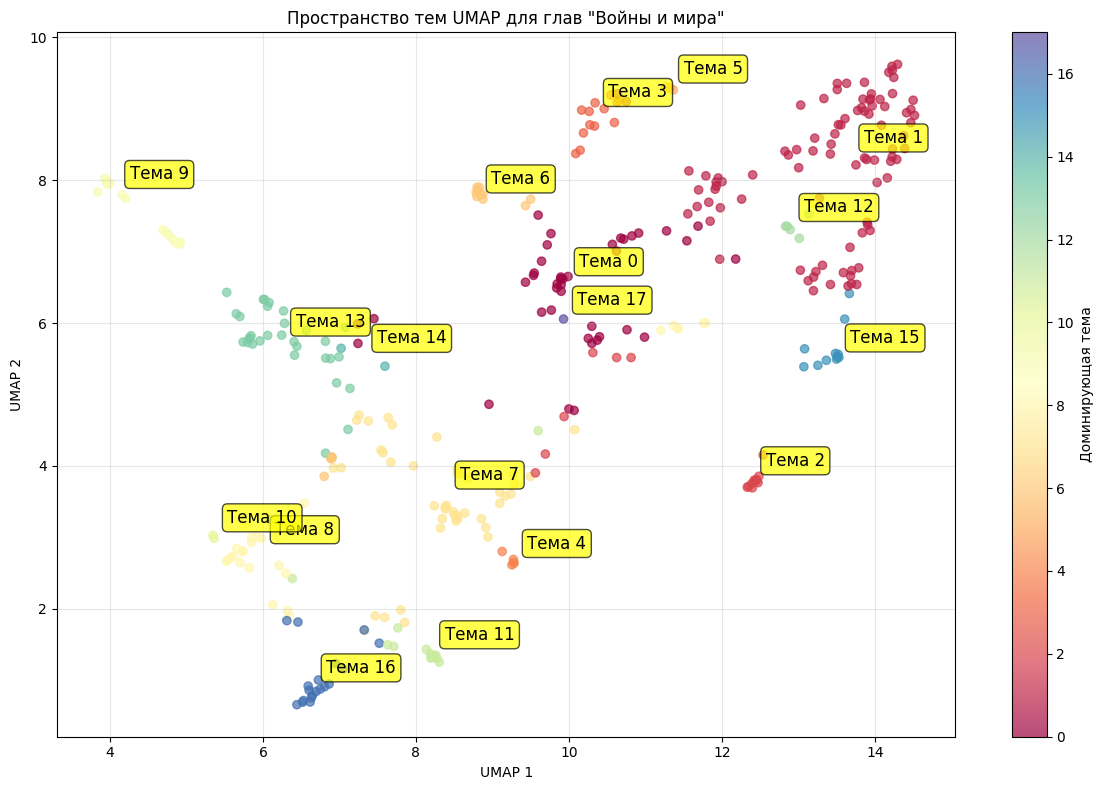

In [16]:
# Извлечение распределений тем для документов
def get_document_topic_distributions(lda_model, corpus):
    doc_topic_distributions = []

    for doc in corpus:
        topic_dist = lda_model.get_document_topics(doc, minimum_probability=0)
        doc_topic_distributions.append([prob for topic_id, prob in topic_dist])

    return np.array(doc_topic_distributions)

# Получение распределений тем
doc_topic_distributions = get_document_topic_distributions(lda_model, corpus)

# Применение UMAP для снижения размерности
umap_embedder = umap.UMAP(
    n_components=2,
    random_state=42,
    metric='hellinger'
)
umap_embeddings = umap_embedder.fit_transform(doc_topic_distributions)

# Визуализация документов в пространстве тем
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    umap_embeddings[:, 0],
    umap_embeddings[:, 1],
    c=np.argmax(doc_topic_distributions, axis=1),
    cmap='Spectral',
    alpha=0.7
)
plt.colorbar(scatter, label='Доминирующая тема')
plt.title('Пространство тем UMAP для глав "Войны и мира"')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

# Добавление информации о доминирующих темах
dominant_topics = np.argmax(doc_topic_distributions, axis=1)
for i, topic_id in enumerate(set(dominant_topics)):
    indices = np.where(dominant_topics == topic_id)[0]
    if len(indices) > 0:
        center = np.median(umap_embeddings[indices], axis=0)
        plt.annotate(
            f'Тема {topic_id}',
            xy=center,
            xytext=(10, 10),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='yellow', alpha=0.7),
            fontsize=12
        )

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

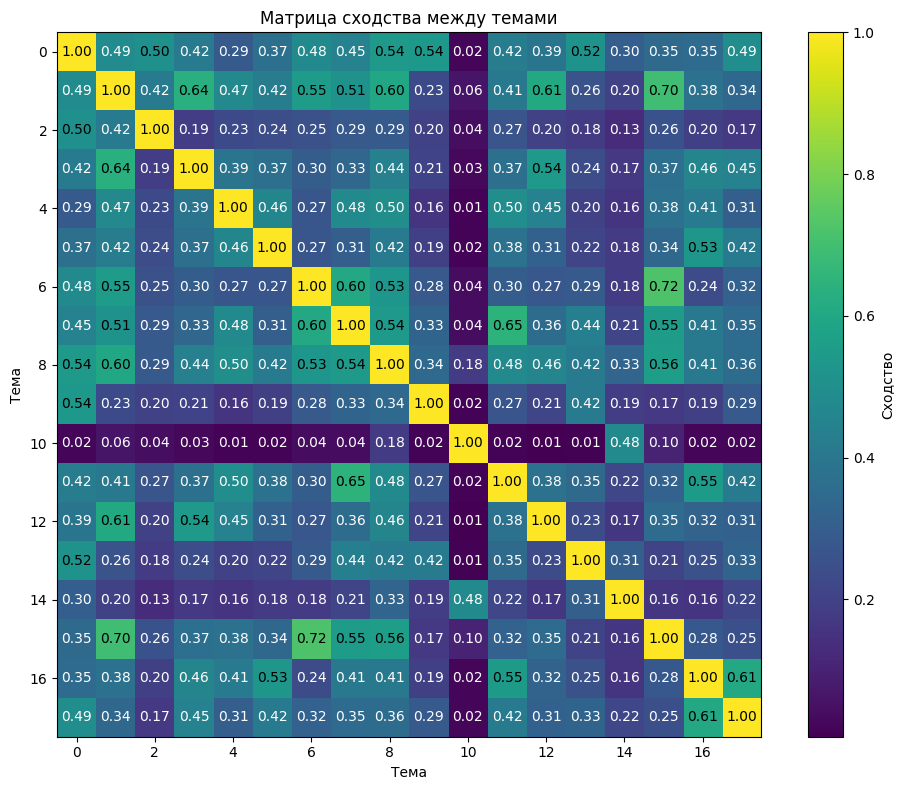

In [17]:
# Матрица сходства между темами
from sklearn.metrics.pairwise import cosine_similarity

def get_topic_similarity_matrix(lda_model, num_topics):
    # Извлечение векторов слов для каждой темы
    topic_vectors = []
    for topic_id in range(num_topics):
        topic_words = lda_model.get_topic_terms(topic_id, topn=50)
        word_vector = np.zeros(len(lda_model.id2word))
        for word_id, weight in topic_words:
            word_vector[word_id] = weight
        topic_vectors.append(word_vector)

    topic_vectors = np.array(topic_vectors)

    # Вычисление косинусного сходства
    similarity_matrix = cosine_similarity(topic_vectors)

    return similarity_matrix

# Получение матрицы сходства
similarity_matrix = get_topic_similarity_matrix(lda_model, 18)

# Визуализация матрицы сходства
plt.figure(figsize=(10, 8))
im = plt.imshow(similarity_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(im, label='Сходство')
plt.title('Матрица сходства между темами')
plt.xlabel('Тема')
plt.ylabel('Тема')

# Добавление значений на матрицу
for i in range(similarity_matrix.shape[0]):
    for j in range(similarity_matrix.shape[1]):
        plt.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                ha='center', va='center', color='white' if similarity_matrix[i, j] < 0.5 else 'black')

plt.tight_layout()
plt.show()

Тема 0:
Ключевые слова: который, свой, человек, пьер, москва, жизнь, говорить, один, время, тот
--------------------------------------------------
Тема 1:
Ключевые слова: сказать, наташа, который, говорить, марья, княжна, свой, князь, пьер, знать
--------------------------------------------------
Тема 2:
Ключевые слова: пьер, который, сказать, человек, свой, француз, говорить, лицо, vous, рука
--------------------------------------------------
Тема 3:
Ключевые слова: николай, наташа, сказать, свой, говорить, который, графиня, соня, мать, ростов
--------------------------------------------------
Тема 4:
Ключевые слова: сказать, командир, полковой, говорить, солдат, рота, офицер, свой, граф, долох
--------------------------------------------------
Тема 5:
Ключевые слова: долох, ростов, сказать, долохов, анатоль, который, свой, знать, говорить, любить
--------------------------------------------------
Тема 6:
Ключевые слова: князь, андрей, который, свой, сказать, говорить, человек, знать,

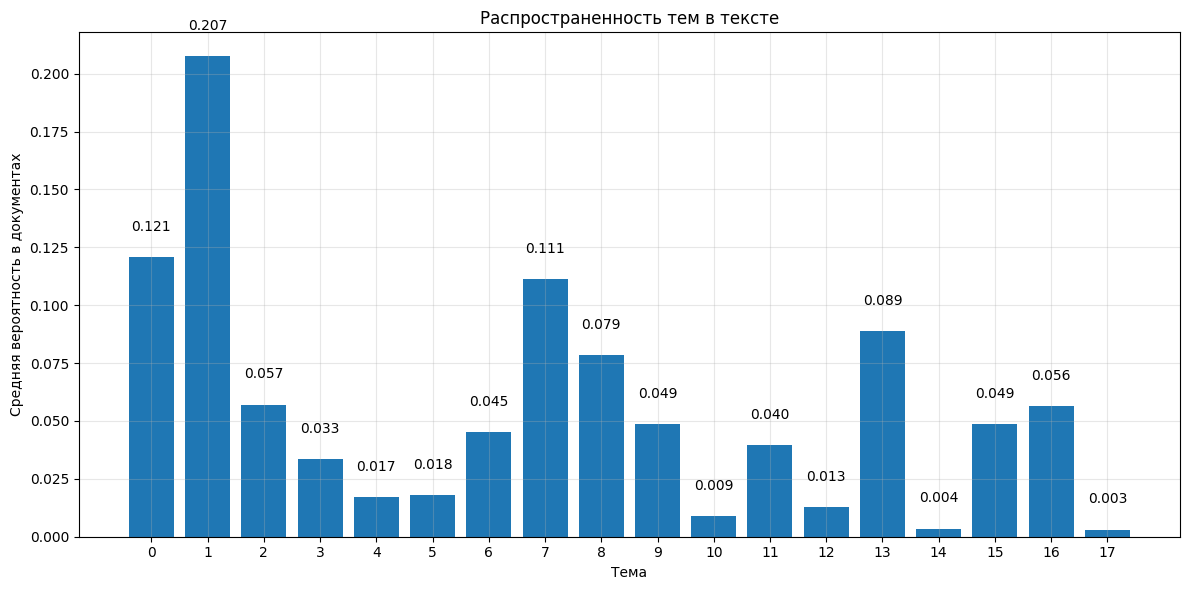

In [19]:
# Детальный анализ каждой темы
def analyze_topics(lda_model, num_topics, num_words=15):
    topic_analysis = {}

    for topic_id in range(num_topics):
        top_words = lda_model.show_topic(topic_id, topn=num_words)
        topic_analysis[topic_id] = {
            'top_words': [word for word, prob in top_words],
            'word_probs': [prob for word, prob in top_words]
        }

        print(f"Тема {topic_id}:")
        print("Ключевые слова:", ", ".join([word for word, prob in top_words[:10]]))
        print("-" * 50)

    return topic_analysis

# Анализ тем
topic_analysis = analyze_topics(lda_model, 18)

# Визуализация важности тем в корпусе
topic_prevalence = np.mean(doc_topic_distributions, axis=0)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(18), topic_prevalence)
plt.xlabel('Тема')
plt.ylabel('Средняя вероятность появления в главах')
plt.title('Распространенность тем в тексте')

# Добавление значений на столбцы
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{topic_prevalence[i]:.3f}', ha='center', va='bottom')

plt.xticks(range(18))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()